# Modelos Generativos: Resumen Automático con mT5

A continuación abordaremos la generación de resúmenes mediante un **enfoque Generativo**. A diferencia de los métodos extractivos, los modelos generativos emplean arquitecturas de Deep Learning basadas en Transformers para "entender" el texto original y redactar un resumen nuevo, fluido y con vocabulario propio.

Utilizaremos el modelo **`josmunpen/mt5-small-spanish-summarization`**, una variante del modelo multilingüe mT5 de Google, reentrenado específicamente por el Instituto de Ingeniería del Conocimiento para la tarea de resumir noticias periodísticas en español.

In [1]:
%pip install -q transformers sentencepiece torch evaluate rouge_score tqdm spacy scikit-learn
!python -m spacy download es_core_news_sm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl (12.9 MB)
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

## 1. Preparación del Entorno y Carga de Datos

Comenzaremos cargando el conjunto de 500 noticias de experimentación. Al cargar el archivo validado del cuaderno anterior, conservaremos las columnas de los resúmenes de Lead-3 y TextRank, lo que nos permitirá hacer la comparativa final en este mismo cuaderno.

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm

In [4]:
df_experimento = pd.read_csv("resultados_extractivos_validados.csv")
df_experimento = df_experimento.dropna(subset=["text", "summary"]).reset_index(drop=True)
print(f"Dataset cargado con {len(df_experimento)} noticias preparadas para experimentación.")
print("Columnas disponibles:", list(df_experimento.columns))
df_experimento.head(3)

Dataset cargado con 500 noticias preparadas para experimentación.
Columnas disponibles: ['text', 'summary', 'topic', 'url', 'title', 'date', 'resumen_lead3', 'resumen_textrank']


,text,summary,topic,url,title,date,resumen_lead3,resumen_textrank
0,El pleno del Parlamento de Cataluña ha burlado...,El tribunal suspende minutos después del pleno...,ccaa catalunya,http://elpais.com/ccaa/2019/11/12/catalunya/15...,El Parlament burla al Constitucional y aprueba...,12/11/2019,El pleno del Parlamento de Cataluña ha burlado...,El pleno del Parlamento de Cataluña ha burlado...
1,"Hasán Rohaní, presidente iraní, este martes. E...",Teherán asegura que las sanciones de EE UU al ...,internacional actualidad,http://elpais.com/internacional/2019/06/25/act...,El presidente de Irán acusa a EEUU de mentir s...,25/06/2019,"Hasán Rohaní, presidente iraní, este martes. E...",EFE / VÍDEO: REUTERS-QUALITY Irán ha respondid...
2,Era horrible. En la primera década de mi vida ...,"Los problemas de una niña superdotada, el abor...",ccaa catalunya,http://elpais.com/ccaa/2019/08/05/catalunya/15...,Nunca más huérfanos de serie,06/08/2019,Era horrible. En la primera década de mi vida ...,Mi madre y mi abuelo —vivía con nosotros— esta...


## 2. Baseline Extractivo Integrado (TF-IDF + spaCy)

Para incorporar la técnica del cuaderno de modelos extractivos en este notebook de entrega, generamos un resumen extractivo TF-IDF sobre el mismo conjunto df_experimento.

In [5]:
nlp = spacy.load("es_core_news_sm")

def preprocess_sentence(sentence):
    doc = nlp(str(sentence).lower())
    clean_tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return " ".join(clean_tokens)

def extractive_summary_tfidf(text, num_sentences=3):
    doc = nlp(str(text))
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]

    if len(sentences) <= num_sentences:
        return " ".join(sentences) if sentences else ""

    clean_sentences = [preprocess_sentence(sent) for sent in sentences]
    vectorizer = TfidfVectorizer()

    try:
        tfidf_matrix = vectorizer.fit_transform(clean_sentences)
    except ValueError:
        return " ".join(sentences[:num_sentences])

    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    top_indices = sentence_scores.argsort()[-num_sentences:]
    top_indices.sort()

    return " ".join([sentences[i] for i in top_indices])

if "resumen_tfidf" not in df_experimento.columns:
    tqdm.pandas(desc="Generando TF-IDF")
    df_experimento["resumen_tfidf"] = df_experimento["text"].progress_apply(
        lambda t: extractive_summary_tfidf(t, num_sentences=3)
    )
    print("Resúmenes TF-IDF generados.")
else:
    print("La columna 'resumen_tfidf' ya existe. Se reutilizará en la comparación.")

Generando TF-IDF: 100%|██████████| 500/500 [01:44<00:00,  4.79it/s]

Resúmenes TF-IDF generados.


## 3. Configuración de Modelos Generativos

Además del modelo `josmunpen/mt5-small-spanish-summarization`, incorporamos las técnicas del cuaderno de modelos generativos:

1. Zero-shot con `csebuetnlp/mT5_multilingual_XLSum`.
2. Modelo fine-tuned local (si existe en disco).

Todos se evalúan sobre el mismo `df_experimento` para mantener una comparación justa.

In [6]:
MODELOS_GENERATIVOS = {
    "mt5_iic": "josmunpen/mt5-small-spanish-summarization",
    "mt5_xlsum": "csebuetnlp/mT5_multilingual_XLSum",
}

RUTA_MODELO_LOCAL = "mi_modelo_resumen_mt5"
if not os.path.exists(RUTA_MODELO_LOCAL):
    ruta_checkpoint = "resultados_mt5_mlsum/checkpoint-3750"
    if os.path.exists(ruta_checkpoint):
        RUTA_MODELO_LOCAL = ruta_checkpoint

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo detectado: {device}")

cache_modelos = {}
cache_tokenizers = {}

def cargar_modelo(model_key):
    if model_key in cache_modelos:
        return cache_tokenizers[model_key], cache_modelos[model_key]

    if model_key == "mt5_finetuned":
        model_name = RUTA_MODELO_LOCAL
    else:
        model_name = MODELOS_GENERATIVOS[model_key]

    print(f"Cargando modelo: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    cache_tokenizers[model_key] = tokenizer
    cache_modelos[model_key] = model
    return tokenizer, model

Dispositivo detectado: cpu


## 4. Generación de Resúmenes (Múltiples Técnicas)

Generamos resúmenes con los modelos de ambos cuadernos usando el mismo conjunto de noticias:

- `resumen_tfidf`: baseline extractivo TF-IDF + spaCy.
- `resumen_mt5_iic`: modelo generativo principal del cuaderno de entrega.
- `resumen_xlsum`: modelo generativo zero-shot (XLSum).
- `resumen_mt5_ft`: modelo fine-tuned local, si está disponible.

In [7]:
tqdm.pandas(desc="Redactando resúmenes")

def resumir_con_modelo(texto, model_key, max_len=150, min_len=30):
    tokenizer, model = cargar_modelo(model_key)
    inputs = tokenizer(str(texto), return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            max_length=max_len,
            min_length=min_len,
            length_penalty=1.0,
            num_beams=4,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

if "resumen_mt5_iic" not in df_experimento.columns:
    df_experimento["resumen_mt5_iic"] = df_experimento["text"].progress_apply(
        lambda t: resumir_con_modelo(t, "mt5_iic")
    )
    print("Resúmenes mT5-IIC generados.")

if "resumen_xlsum" not in df_experimento.columns:
    df_experimento["resumen_xlsum"] = df_experimento["text"].progress_apply(
        lambda t: resumir_con_modelo(t, "mt5_xlsum")
    )
    print("Resúmenes mT5-XLSum generados.")

if os.path.exists(RUTA_MODELO_LOCAL):
    if "resumen_mt5_ft" not in df_experimento.columns:
        df_experimento["resumen_mt5_ft"] = df_experimento["text"].progress_apply(
            lambda t: resumir_con_modelo(t, "mt5_finetuned")
        )
        print("Resúmenes mT5 fine-tuned generados.")
else:
    print("No se encontró un modelo fine-tuned local; se omite esta técnica.")

print("Generación completada.")

Redactando resúmenes:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando modelo: josmunpen/mt5-small-spanish-summarization


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

c:\Users\jcaba\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jcaba\.cache\huggingface\hub\models--josmunpen--mt5-small-spanish-summarization. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

...

Redactando resúmenes:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando modelo: mi_modelo_resumen_mt5


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Redactando resúmenes: 100%|██████████| 500/500 [23:31<00:00,  2.82s/it]

Resúmenes mT5 fine-tuned generados.
Generación completada.


## 5. Evaluación Final Unificada
Calculamos ROUGE para todos los enfoques (extractivos y generativos) sobre el mismo dataset de comparación.

In [8]:
import evaluate

rouge = evaluate.load("rouge")

modelos_a_evaluar = [
    ("Lead-3", "resumen_lead3"),
    ("TextRank", "resumen_textrank"),
    ("TF-IDF + spaCy", "resumen_tfidf"),
    ("mT5 IIC", "resumen_mt5_iic"),
    ("mT5 XLSum", "resumen_xlsum"),
    ("mT5 Fine-Tuned", "resumen_mt5_ft"),
]

resultados = []
for nombre_modelo, col in modelos_a_evaluar:
    if col not in df_experimento.columns:
        print(f"Se omite {nombre_modelo}: columna '{col}' no disponible.")
        continue

    print(f"Evaluando {nombre_modelo}...")
    metricas = rouge.compute(
        predictions=df_experimento[col].fillna("").astype(str).tolist(),
        references=df_experimento["summary"].fillna("").astype(str).tolist(),
    )
    metricas["Modelo"] = nombre_modelo
    resultados.append(metricas)

df_metricas_finales = pd.DataFrame(resultados).set_index("Modelo")

print("\n>>> Resultados Numéricos (F1-Score):")
display(df_metricas_finales.sort_values("rougeL", ascending=False))

Evaluando Lead-3...
Evaluando TextRank...
Evaluando TF-IDF + spaCy...
Evaluando mT5 IIC...
Evaluando mT5 XLSum...
Evaluando mT5 Fine-Tuned...

>>> Resultados Numéricos (F1-Score):


,rouge1,rouge2,rougeL,rougeLsum
Modelo,,,,
mT5 Fine-Tuned,0.244867,0.062989,0.184271,0.184381
mT5 IIC,0.243608,0.055758,0.180775,0.180570
mT5 XLSum,0.227841,0.051977,0.169959,0.170048
Lead-3,0.207654,0.065776,0.149273,0.149367
TextRank,0.191095,0.061951,0.138480,0.138548
TF-IDF + spaCy,0.146041,0.045159,0.106589,0.106747


## 6. Visualización y Guardado

Mostramos la comparación global y guardamos los resultados para el informe final.

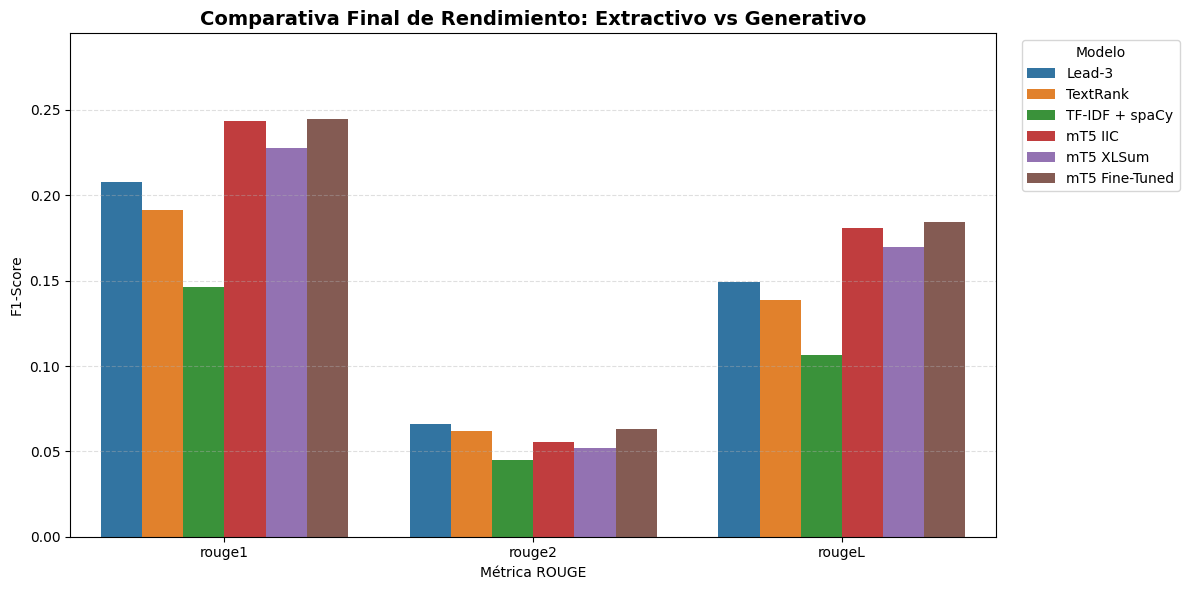

Archivos guardados: resultados_finales.csv, metricas_finales.csv y grafica_final_proyecto.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot_final = df_metricas_finales.reset_index().rename(columns={"index": "Modelo"})
df_plot_final = df_plot_final.melt(
    id_vars="Modelo",
    value_vars=["rouge1", "rouge2", "rougeL"],
    var_name="Métrica ROUGE",
    value_name="F1-Score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot_final, x="Métrica ROUGE", y="F1-Score", hue="Modelo")

plt.title("Comparativa Final de Rendimiento: Extractivo vs Generativo", fontsize=14, fontweight="bold")
plt.ylim(0, min(1.0, df_plot_final["F1-Score"].max() + 0.05))
plt.ylabel("F1-Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("grafica_final_proyecto.png", dpi=300)
plt.show()

df_experimento.to_csv("resultados_finales.csv", index=False)
df_metricas_finales.sort_values("rougeL", ascending=False).to_csv("metricas_finales.csv")
print("Archivos guardados: resultados_finales.csv, metricas_finales.csv y grafica_final_proyecto.png")

### 7. Conclusiones

Este notebook integra en un solo flujo las técnicas de los tres cuadernos del proyecto:

1. Baselines extractivos (Lead-3, TextRank y TF-IDF + spaCy).
2. Modelos generativos preentrenados (mT5 IIC y mT5 XLSum).
3. Modelo generativo fine-tuned local (cuando está disponible).

La comparación final se ha realizado usando el mismo conjunto `df_experimento`, lo que permite una evaluación consistente y directa entre enfoques extractivos y generativos.